In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

<H1>Part One: Load Data</H1>

In [2]:
# Load data
df = pd.read_csv("gaming_difficulty_retention.csv")

In [ ]:
# Feature variables
X = df[["difficulty", "total_playtime_hours", "sessions_played", "completion_status"]]

# Target variable 
y = df["retained_7days"]

<H1>Part Two: Cleaning Data</H1>

In [14]:
X.isnull().sum()

difficulty              0
total_playtime_hours    0
sessions_played         0
completion_status       0
dtype: int64

In [15]:
df.dtypes

player_id                      int64
difficulty                    object
total_playtime_hours         float64
sessions_played                int64
retained_7days                 int64
retained_30days                int64
completion_status              int64
Retention Status (7-day)      object
Retention Status (30-day)     object
Playtime                      object
dtype: object

In [16]:
df.isnull().sum()

player_id                    0
difficulty                   0
total_playtime_hours         0
sessions_played              0
retained_7days               0
retained_30days              0
completion_status            0
Retention Status (7-day)     0
Retention Status (30-day)    0
Playtime                     0
dtype: int64

<H1>Part Three: Preprocessing </H1>

In [4]:
# Preprocessing
numeric_features = ["total_playtime_hours", "sessions_played", "completion_status"]
categorical_features = ["difficulty"]

In [ ]:
# Using median imputation so that missing values get filled with the median of that column, so that we don't lose rows.
# Categorical column (difficulty) uses most frequent imputation, filling the missing values with the most common difficulty.
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

In [6]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [8]:
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# What does the Roc-Auc tell us about the model's performance?
# The ROC-AUC score indicates how well the model can distinguish between the two classes (retained vs not retained). 
# A score of 0.5 means the model is no better than random guessing, while a score of 1.0 means perfect classification. 
# A higher ROC-AUC score suggests that the model has a good ability to rank positive instances higher than negative ones, 
# which is important for imbalanced datasets like this one.

Accuracy: 0.73
ROC-AUC: 0.7472410865874363


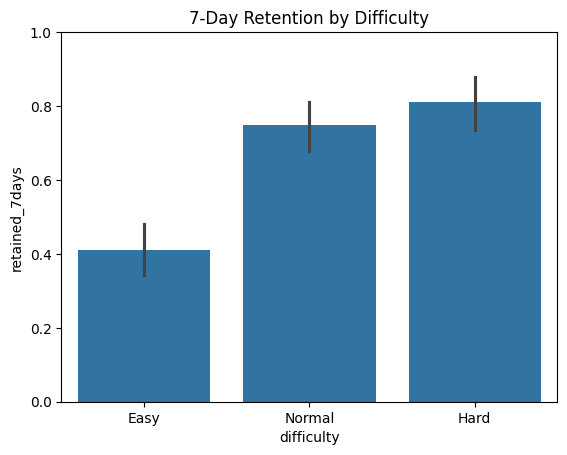

In [ ]:
# Plot 1: Retention by difficulty
sns.barplot(data=df, x="difficulty", y="retained_7days", order=["Easy", "Normal", "Hard"])
plt.title("7-Day Retention by Difficulty")
plt.ylim(0, 1)
plt.show()

# 0 being players not retained at 7 days, 1 being players retained at 7 days


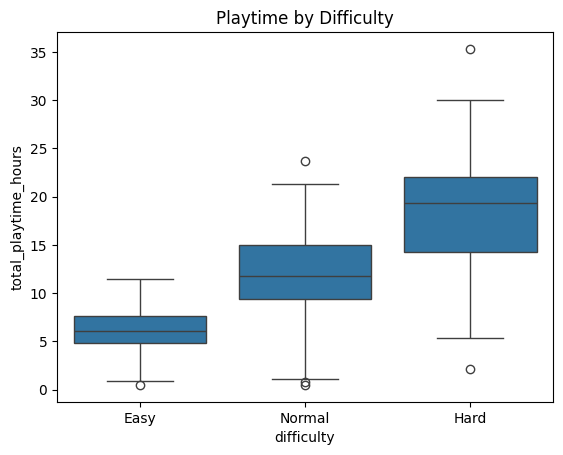

In [ ]:
# Plot 2: Playtime by difficulty
sns.boxplot(data=df, x="difficulty", y="total_playtime_hours", order=["Easy", "Normal", "Hard"])
plt.title("Playtime by Difficulty")
plt.show()

# This graph tells us how long players stick with each difficulty level. 
# If players who choose "Hard" have significantly higher playtime, it may indicate that they are more engaged and likely to be retained.

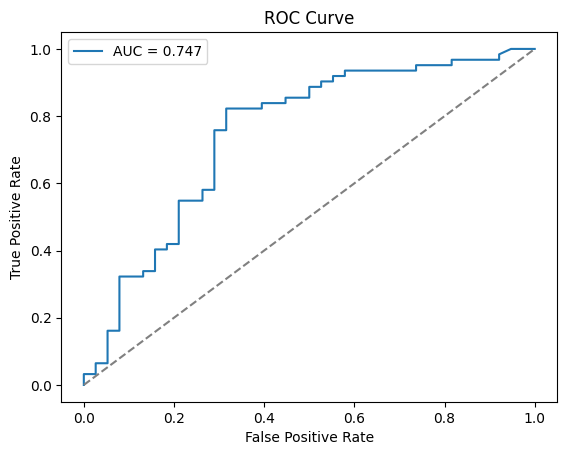

In [12]:
# Plot 3: ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()